# Testing against other software libraries

In [20]:
import autograd.numpy as np
from sklearn.model_selection import train_test_split


## Generate dataset equal to part_b

In [21]:
# custom imports
import source.OLS_functions as OLS_func
from source.runge_preprocessing import TEST_TRAIN_RANDOM_STATE, TEST_SPLIT, x, x_test, y, y_noise, DATAPOINTS

In [22]:
# Same data as in part_b


## Settings OLS

VERBOSE_POLY_DEGREE = False

USE_INTERCEPT = True
polynomial_degree = 15

## Code from project 1 to calculate OLS regression
X = OLS_func.polynomial_features(x, polynomial_degree,USE_INTERCEPT)
X_train_ols, X_test_ols, y_train_ols, y_test_ols = train_test_split(X, y_noise, test_size=TEST_SPLIT, random_state=TEST_TRAIN_RANDOM_STATE) 
# Scaleing
X_train_scaled_ols, X_test_scaled_ols, X_train_mean_ols, X_train_std_ols = OLS_func.scale_features_by_intercept_use(X_train_ols, X_test_ols, USE_INTERCEPT)
y_train_scaled_ols, y_test_scaled_ols, y_train_mean_ols, y_train_std_ols = OLS_func.standard_scaler(y_train_ols, y_test_ols)

# Train
theata_scaled = OLS_func.OLS_parameters(X_train_scaled_ols, y_train_scaled_ols)

# Predict
rescaled_theta, rescaled_intercept = OLS_func.rescale_theta_intercept(theata_scaled[1:], theata_scaled[0], y_train_std_ols, y_train_mean_ols, X_train_std_ols, X_train_mean_ols, verbose=VERBOSE_POLY_DEGREE)
y_predicted_scaled_ols = OLS_func.predict_y(X_test_scaled_ols[:, 1:], rescaled_theta)
y_predicted_rescaled_ols = OLS_func.rescale_y(y_predicted_scaled_ols, y_train_std_ols, y_train_mean_ols)
polynomial_degree, mse_train_ols, mse_test_ols, r2_train_ols, r2_test_ols, thetas_ols = OLS_func.explore_polynomial_degree(X_train_scaled_ols, X_test_scaled_ols, y_train_scaled_ols, y_test_scaled_ols, polynomial_degree, USE_INTERCEPT, verbose=VERBOSE_POLY_DEGREE)

y_train_scaled_ols = np.array(y_train_scaled_ols).reshape(-1, 1)
y_test_scaled_ols = np.array(y_test_scaled_ols).reshape(-1, 1)


## PyTorch regression

Raschka page 435 - 436


In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from source.utils import pytorch_loop

from source.plotting import plot_runges_two_predictions, plot_heatmap



In [24]:
# Use design matrix made in part_b

X_train_scaled_tensor = torch.tensor(X_train_scaled_ols, dtype=torch.float32)
X_test_scaled_tensor = torch.tensor(X_test_scaled_ols, dtype=torch.float32)

y_train_scaled_tensor = torch.tensor(y_train_scaled_ols, dtype=torch.float32)
y_test_scaled_tensor = torch.tensor(y_test_scaled_ols, dtype=torch.float32)




In [25]:
# settings for this task

VERBOSE = True
SAVE_FIGURE = True

ETA_VALUES = [0.01, 0.001, 0.0001, 0.00001] 
LAMBDA_VALUES = [0] #We use lambda = 0 in part_c only compareing to part_b

ffnn_iterations = 10

batch_size_val = 256

torch.manual_seed(1)





## 50 and 100 nodes in two hidden layers

In [26]:
# model generation - ensure new model each iteration

def model_50_100_fn(verbose=VERBOSE):
    """
    Docstring created with Copilot

    Creates a feedforward neural network with specified hidden layers and sigmoid activations.

    Parameters:
        input_data (torch.Tensor or np.ndarray): Used to determine input feature size.

    Returns:
        nn.Sequential: A PyTorch model.
    """
    hidden_units = [50, 100]
    input_size = X_train_scaled_tensor.shape[1]
    layers = []

    for hidden_unit in hidden_units:
        layers.append(nn.Linear(input_size, hidden_unit))
        layers.append(nn.Sigmoid())  
        input_size = hidden_unit

    layers.append(nn.Linear(input_size, 1))  # Output layer

    model = nn.Sequential(*layers)

    if verbose: print(model)  # Optional: for inspection

    return model



In [27]:
# loop through learning rates

# Plain SGD
momentum_val = 0 # Plain gradient descent
weight_decay_val = 0 # no lambda
pytorch_plain_SGD_results_50_100 = pytorch_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'SGD', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, momentum=momentum_val, weight_decay=weight_decay_val, batch_size=batch_size_val, verbose=VERBOSE) 

# RMSprop 
momentum_val = 0 # Plain gradient descent
weight_decay_val = 0 # no lambda
rho1_val = 0.9
pytorch_RMSprop_results_50_100 = pytorch_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, momentum=momentum_val, rho=rho1_val, weight_decay=weight_decay_val, batch_size=batch_size_val, verbose=VERBOSE) 

# ADAM
weight_decay_val = 0 # no lambda
rho1_val = 0.9
rho2_val = 0.999
pytorch_ADAM_results_50_100 = pytorch_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, momentum=momentum_val, rho=rho1_val, weight_decay=weight_decay_val, rho2=rho2_val, batch_size=batch_size_val, verbose=VERBOSE) 



Training with optimizer=SGD, lr=0.01, lambda=0, iterations=10
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=100, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=100, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.0183
Test MSE: 1.0387

Training with optimizer=SGD, lr=0.001, lambda=0, iterations=10
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=100, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=100, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.0276
Test MSE: 1.0453

Training with optimizer=SGD, lr=0.0001, lambda=0, iterations=10
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=100, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=100, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.0294
Test MSE:

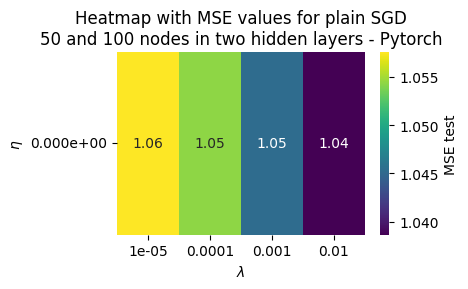

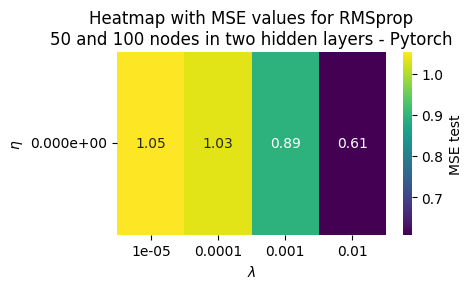

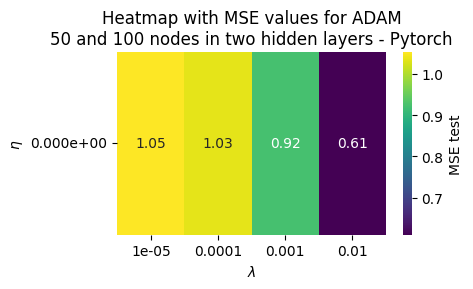

In [28]:
if SAVE_FIGURE:
    plot_heatmap(pytorch_plain_SGD_results_50_100, 'MSE test', title='Heatmap with MSE values for plain SGD\n50 and 100 nodes in two hidden layers - Pytorch', filename='part_c-heatmap-plain-sgd-50_100-pytorch')
    plot_heatmap(pytorch_RMSprop_results_50_100, 'MSE test', title='Heatmap with MSE values for RMSprop\n50 and 100 nodes in two hidden layers - Pytorch', filename='part_c-heatmap-rmsprop-50_100-pytorch')
    plot_heatmap(pytorch_ADAM_results_50_100, 'MSE test', title='Heatmap with MSE values for ADAM\n50 and 100 nodes in two hidden layers - Pytorch', filename='part_c-heatmap-adam-50_100-pytorch')

In [29]:

# Rescale plain SGD
pytorch_min_index_plain_SGD_results_50_100 = pytorch_plain_SGD_results_50_100['MSE test'].idxmin()
pytorch_best_predictions_plain_SGD_results_50_100 = pytorch_plain_SGD_results_50_100.loc[pytorch_min_index_plain_SGD_results_50_100]['Predictions']
pytorch_best_predictions_plain_SGD_results_50_100_rescaled  = OLS_func.rescale_y(pytorch_best_predictions_plain_SGD_results_50_100, y_train_std_ols, y_train_mean_ols)


# Rescale RMSprop
pytorch_min_index_RMSprop_results_50_100 = pytorch_RMSprop_results_50_100['MSE test'].idxmin()
pytorch_best_best_predictions_RMSprop_results_50_100 = pytorch_RMSprop_results_50_100.loc[pytorch_min_index_RMSprop_results_50_100]['Predictions']
pytorch_best_predictions_RMSprop_results_50_100_rescaled  = OLS_func.rescale_y(pytorch_best_best_predictions_RMSprop_results_50_100, y_train_std_ols, y_train_mean_ols)

# Rescale ADAM
pytorch_min_index_ADAM_results_50_100 = pytorch_ADAM_results_50_100['MSE test'].idxmin()
pytorch_best_best_predictions_ADAM_results_50_100 = pytorch_ADAM_results_50_100.loc[pytorch_min_index_ADAM_results_50_100]['Predictions']
pytorch_best_predictions_ADAM_results_50_100_rescaled  = OLS_func.rescale_y(pytorch_best_best_predictions_ADAM_results_50_100, y_train_std_ols, y_train_mean_ols)

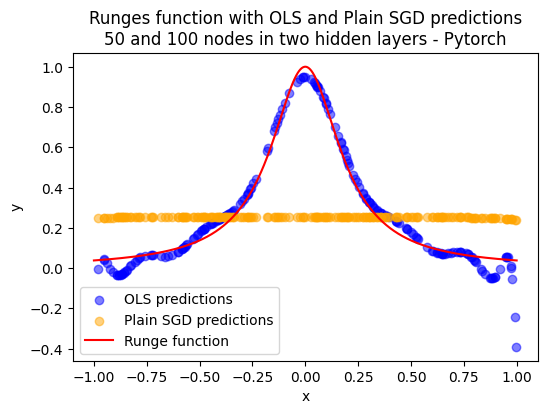

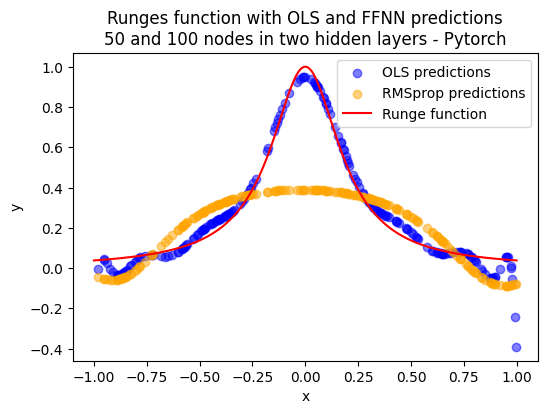

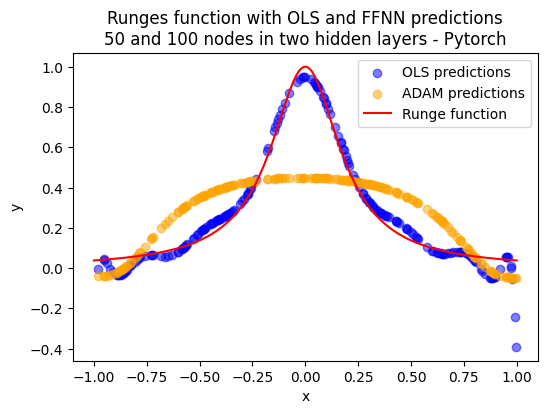

In [30]:
# Plot Runges Pytorch based on best MSE test value

if SAVE_FIGURE:
    # Plotting Runge function and predictions from OLS regression and FFNN
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_plain_SGD_results_50_100_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='Plain SGD predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and Plain SGD predictions\n50 and 100 nodes in two hidden layers - Pytorch',
                                                            filename=f'part_c-runges_OLS_FFNN_predcitions-50_100_hidden_layers - Pytorch', save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)
                                                            
    
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_RMSprop_results_50_100_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='RMSprop predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 and 100 nodes in two hidden layers - Pytorch',
                                                            filename=f'part_c-runges_OLS_rmsprop_predcitions-50_100_hidden_layers - Pytorch', save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_ADAM_results_50_100_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='ADAM predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 and 100 nodes in two hidden layers - Pytorch',
                                                            filename=f'part_c-runges_OLS_rmsprop_predcitions-50_100_hidden_layers - Pytorch', save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

## 50 nodes in one hidden layers

In [31]:
# model generation - ensure new model each iteration

def model_50_fn(verbose=VERBOSE):
    """
    Docstring created with Copilot

    Creates a feedforward neural network with specified hidden layers and sigmoid activations.

    Parameters:
        input_data (torch.Tensor or np.ndarray): Used to determine input feature size.

    Returns:
        nn.Sequential: A PyTorch model.
    """
    hidden_units = [50]
    input_size = X_train_scaled_tensor.shape[1]
    layers = []

    for hidden_unit in hidden_units:
        layers.append(nn.Linear(input_size, hidden_unit))
        layers.append(nn.Sigmoid())  
        input_size = hidden_unit

    layers.append(nn.Linear(input_size, 1))  # Output layer

    model = nn.Sequential(*layers)

    if verbose: print(model)  # Optional: for inspection

    return model


In [32]:
# loop through learning rates

# Plain SGD
momentum_val = 0 # Plain gradient descent
weight_decay_val = 0 # no lambda
pytorch_plain_SGD_results_50 = pytorch_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'SGD', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, momentum=momentum_val, weight_decay=weight_decay_val, batch_size=batch_size_val, verbose=VERBOSE) 

# RMSprop 
momentum_val = 0 # Plain gradient descent
weight_decay_val = 0 # no lambda
rho1_val = 0.9
pytorch_RMSprop_results_50 = pytorch_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, momentum=momentum_val, rho=rho1_val, weight_decay=weight_decay_val, batch_size=batch_size_val, verbose=VERBOSE) 

# ADAM
weight_decay_val = 0 # no lambda
rho1_val = 0.9
rho2_val = 0.999
pytorch_ADAM_results_50 = pytorch_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, momentum=momentum_val, rho=rho1_val, weight_decay=weight_decay_val, rho2=rho2_val, batch_size=batch_size_val, verbose=VERBOSE) 



Training with optimizer=SGD, lr=0.01, lambda=0, iterations=10
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=1, bias=True)
)
Epoch 0: Training Loss = 0.9784
Test MSE: 0.9149

Training with optimizer=SGD, lr=0.001, lambda=0, iterations=10
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.0596
Test MSE: 1.0096

Training with optimizer=SGD, lr=0.0001, lambda=0, iterations=10
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.0732
Test MSE: 1.1673

Training with optimizer=SGD, lr=1e-05, lambda=0, iterations=10
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=1, bias=True)
)
Epoch 0: Trai

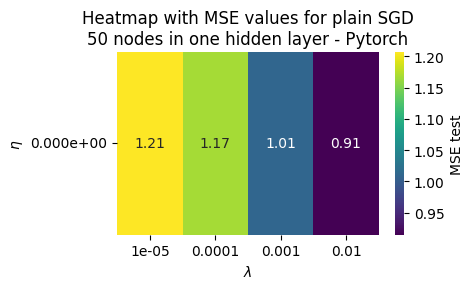

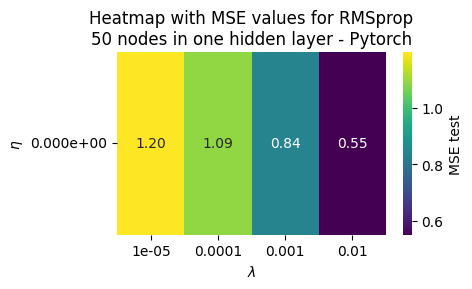

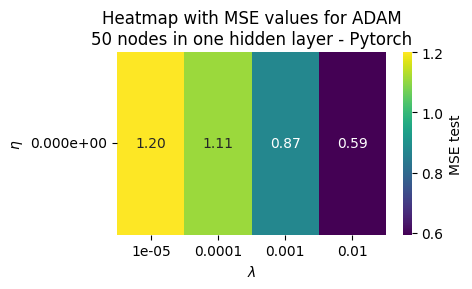

In [33]:
if SAVE_FIGURE:
    plot_heatmap(pytorch_plain_SGD_results_50, 'MSE test', title='Heatmap with MSE values for plain SGD\n50 nodes in one hidden layer - Pytorch', filename='part_c-heatmap-plain-sgd-50-pytorch')
    plot_heatmap(pytorch_RMSprop_results_50, 'MSE test', title='Heatmap with MSE values for RMSprop\n50 nodes in one hidden layer - Pytorch', filename='part_c-heatmap-rmsprop-50-pytorch')
    plot_heatmap(pytorch_ADAM_results_50, 'MSE test', title='Heatmap with MSE values for ADAM\n50 nodes in one hidden layer - Pytorch', filename='part_c-heatmap-adam-50-pytorch')

In [34]:

# Rescale plain SGD
pytorch_min_index_plain_SGD_results_50 = pytorch_plain_SGD_results_50['MSE test'].idxmin()
pytorch_best_predictions_plain_SGD_results_50 = pytorch_plain_SGD_results_50.loc[pytorch_min_index_plain_SGD_results_50]['Predictions']
pytorch_best_predictions_plain_SGD_results_50_rescaled  = OLS_func.rescale_y(pytorch_best_predictions_plain_SGD_results_50, y_train_std_ols, y_train_mean_ols)


# Rescale RMSprop
pytorch_min_index_RMSprop_results_50 = pytorch_RMSprop_results_50['MSE test'].idxmin()
pytorch_best_best_predictions_RMSprop_results_50 = pytorch_RMSprop_results_50.loc[pytorch_min_index_RMSprop_results_50]['Predictions']
pytorch_best_predictions_RMSprop_results_50_rescaled  = OLS_func.rescale_y(pytorch_best_best_predictions_RMSprop_results_50, y_train_std_ols, y_train_mean_ols)

# Rescale ADAM
pytorch_min_index_ADAM_results_50 = pytorch_ADAM_results_50['MSE test'].idxmin()
pytorch_best_best_predictions_ADAM_results_50 = pytorch_ADAM_results_50.loc[pytorch_min_index_ADAM_results_50]['Predictions']
pytorch_best_predictions_ADAM_results_50_rescaled  = OLS_func.rescale_y(pytorch_best_best_predictions_ADAM_results_50, y_train_std_ols, y_train_mean_ols)

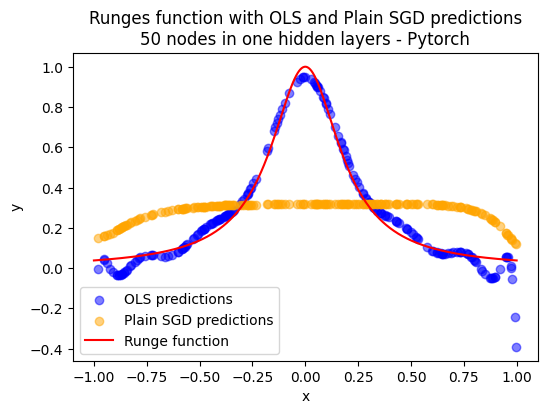

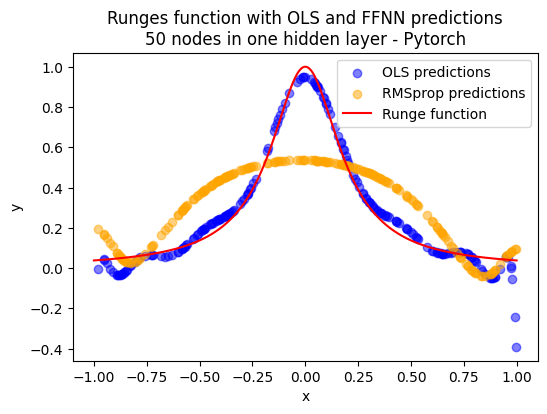

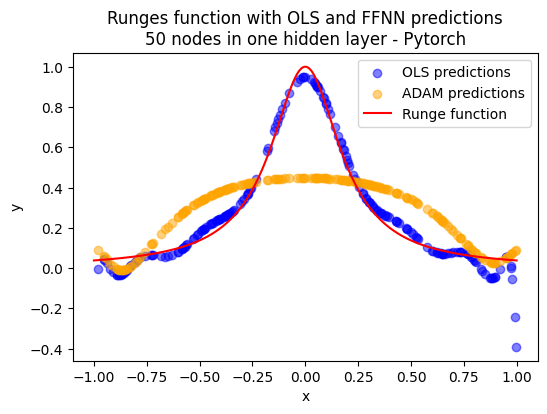

In [35]:
# Plot Runges Pytorch based on best MSE test value

if SAVE_FIGURE:
    # Plotting Runge function and predictions from OLS regression and FFNN
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_plain_SGD_results_50_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='Plain SGD predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and Plain SGD predictions\n50 nodes in one hidden layers - Pytorch',
                                                            filename=f'part_c-runges_OLS_FFNN_predcitions-50_hidden_layers - Pytorch', save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)
                                                            
    
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_RMSprop_results_50_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='RMSprop predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 nodes in one hidden layer - Pytorch',
                                                            filename=f'part_c-runges_OLS_rmsprop_predcitions-50_hidden_layers - Pytorch', save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_ADAM_results_50_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='ADAM predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 nodes in one hidden layer - Pytorch',
                                                            filename=f'part_c-runges_OLS_rmsprop_predcitions-50_hidden_layers - Pytorch', save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

# Comparing gradients from own implementation and autograd

In [36]:
from source.neural_network import NN

In [37]:
# Creating own implementaion of NN model

from source.utils import decide_activation_func, create_activations_layderdim
from source.cost_functions import class_mse_loss


## Hidden layers
hidden_50_100 = (50, 100)
act_func_task = 'sigmoid'     # Choose from 'RELU'  'LRELU' 'sigmoid'


## Set up input, hidden, and output layers and dimensions
activaton_func_50_100, activaton_func_derivative_50_100, output_func_50_100, output_func_derivative = decide_activation_func(act_func_task)
activations_50_100, activations_derivative_50_100, _dim_50_100 = create_activations_layderdim(activaton_func_50_100, activaton_func_derivative_50_100, 
                                                                         output_func_50_100, output_func_derivative, 
                                                                         hidden_50_100, y_train_scaled_ols, X_train_scaled_ols)

cost_fn = class_mse_loss(l1=0, l2=0) 
runge_NN = NN(_dim_50_100, activations_50_100, activations_derivative_50_100, cost_object=cost_fn)

In [38]:
# Functions for compareing autograd and own computation of gradients is a part of NN class

from source.runge_preprocessing import x_test, y_test
runge_NN.compare_gradients(X = X_train_scaled_ols, targets = y_train_scaled_ols)




Compare gradients between own and autograd calculations:
Layer 0: dW match: True, db match: True
Layer 1: dW match: True, db match: True
Layer 2: dW match: True, db match: True

Differences between own and autograd gradients
Layer 0 - dW diff:
[[ 6.66133815e-16 -2.22044605e-16  4.44089210e-16 -2.22044605e-16
   1.11022302e-16  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -5.55111512e-17  0.00000000e+00  5.55111512e-17  0.00000000e+00
  -1.11022302e-16  0.00000000e+00  0.00000000e+00 -2.77555756e-17
  -5.55111512e-17  0.00000000e+00  2.22044605e-16  0.00000000e+00
  -5.55111512e-17 -1.38777878e-17  0.00000000e+00  0.00000000e+00
   0.00000000e+00 -5.55111512e-17  4.44089210e-16 -5.55111512e-17
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.11022302e-16  0.00000000e+00 -2.22044605e-16
   0.00000000e+00 -4.44089210e-16 -2.77555756e-17 -1.11022302e-16
   0.00000000e+00  0.00000000e+00  0.00000000e+00  2.77555756e-17
   0.00000000e+00  0.00000000